<a href="https://colab.research.google.com/github/BintangPancahaya/PCVK26_06_BintangPP/blob/main/Week6_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell Identitas
NAMA = 'Bintang Pancahaya P'
NIM  = '244107020115'   # ganti dengan NIM sendiri

print(NAMA, NIM)


Bintang Pancahaya P 244107020115


In [2]:
# Akses file yang terdapat pada drive
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im


In [4]:
def convolution2d(image, kernel, stride, padding):
    img = image.astype(np.float64)
    kh, kw = kernel.shape

    # duplikasi elemen pinggir citra sebanyak 'padding' piksel
    img_pad = cv.copyMakeBorder(img, padding, padding, padding, padding, cv.BORDER_REPLICATE)

    H, W = img.shape
    out_h = (H + 2 * padding - kh) // stride + 1
    out_w = (W + 2 * padding - kw) // stride + 1

    hasil = np.zeros((out_h, out_w))

    for y in range(out_h):
        for x in range(out_w):
            z = 0
            for k1 in range(kh):
                for k2 in range(kw):
                    z = z + kernel[k1, k2] * img_pad[y * stride + k1, x * stride + k2]
            hasil[y, x] = z

    hasil = np.clip(hasil, 0, 255).astype(np.uint8)
    return hasil


In [5]:

img = cv.imread('/content/drive/MyDrive/PCVK/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


In [6]:
# Menentukan kernel yang akan digunakan (kernel untuk filter sharpening)
kernel_sharpen = np.array([[0, -1, 0],
                            [-1, 5, -1],
                            [0, -1, 0]])


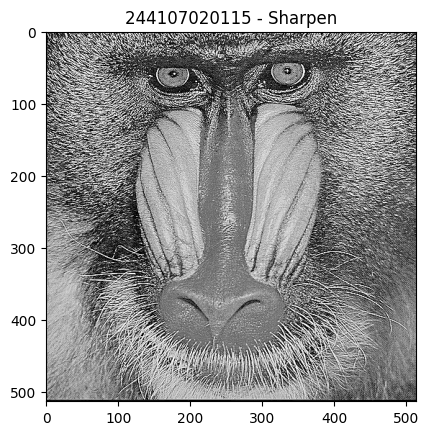

In [7]:
# Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil konvolusinya
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

plt.imshow(hasil_sharpen, cmap='gray')
plt.title(NIM + ' - Sharpen')
plt.show()


### 3. Image Filter: Average filter, Low Pass Filter, High Pass Filter, dan beberapa filter lainnya

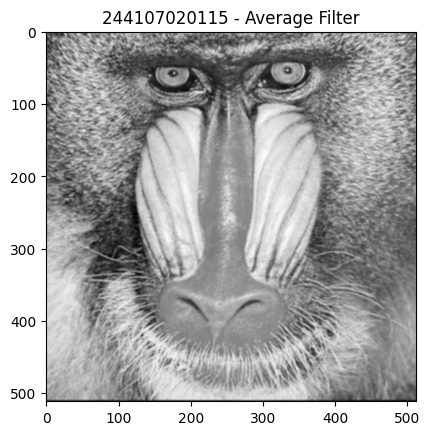

In [8]:
# Filter: Average Filter 3x3
kernel_average = (1/9) * np.array([[1, 1, 1],
                                    [1, 1, 1],
                                    [1, 1, 1]])

hasil_average = convolution2d(img_gray, kernel_average, 1, 1)

plt.imshow(hasil_average, cmap='gray')
plt.title(NIM + ' - Average Filter')
plt.show()


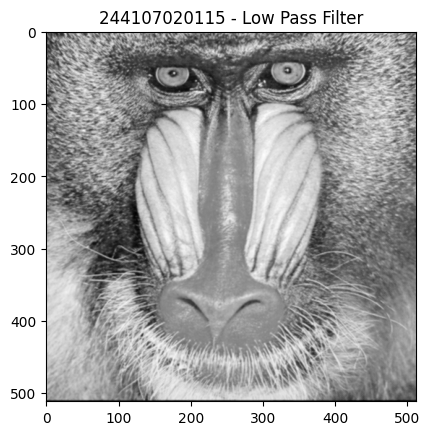

In [9]:
# Filter: Low Pass Filter
kernel_lowpass = (1/12) * np.array([[1, 1, 1],
                                     [1, 4, 1],
                                     [1, 1, 1]])

hasil_lowpass = convolution2d(img_gray, kernel_lowpass, 1, 1)

plt.imshow(hasil_lowpass, cmap='gray')
plt.title(NIM + ' - Low Pass Filter')
plt.show()


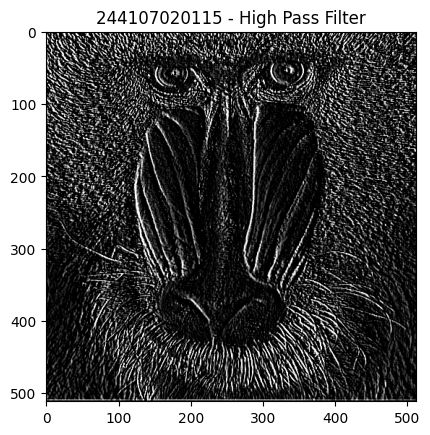

In [10]:
# Filter: High Pass Filter
kernel_highpass = np.array([[-1, 0, 1],
                             [-1, 0, 3],
                             [-3, 0, 1]])

hasil_highpass = convolution2d(img_gray, kernel_highpass, 1, 1)

plt.imshow(hasil_highpass, cmap='gray')
plt.title(NIM + ' - High Pass Filter')
plt.show()


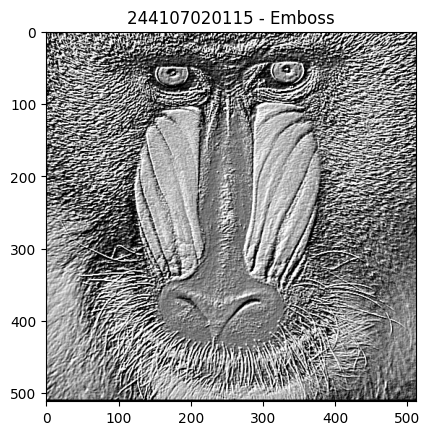

In [11]:
# Filter: Emboss
kernel_emboss = np.array([[-2, -1, 0],
                           [-1,  1, 1],
                           [ 0,  1, 2]])

hasil_emboss = convolution2d(img_gray, kernel_emboss, 1, 1)

plt.imshow(hasil_emboss, cmap='gray')
plt.title(NIM + ' - Emboss')
plt.show()


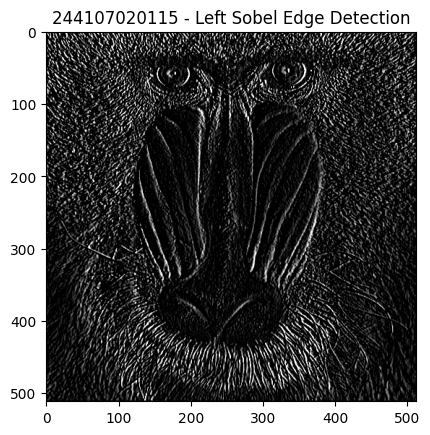

In [12]:
# Filter: Left Sobel Edge Detection
kernel_left_sobel = np.array([[1, 0, -1],
                               [2, 0, -2],
                               [1, 0, -1]])

hasil_left_sobel = convolution2d(img_gray, kernel_left_sobel, 1, 1)

plt.imshow(hasil_left_sobel, cmap='gray')
plt.title(NIM + ' - Left Sobel Edge Detection')
plt.show()


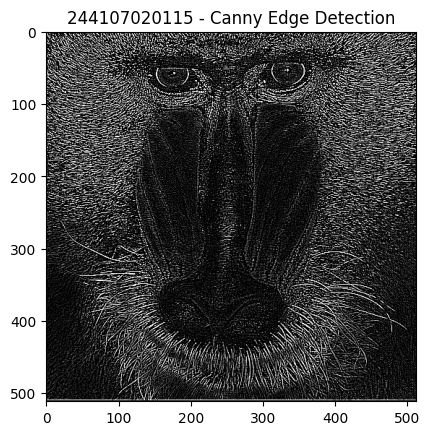

In [13]:
# Filter: Canny Edge Detection (kernel sesuai tabel modul)
kernel_canny = np.array([[-1, -1, -1],
                          [-1,  8, -1],
                          [-1, -1, -1]])

hasil_canny = convolution2d(img_gray, kernel_canny, 1, 1)

plt.imshow(hasil_canny, cmap='gray')
plt.title(NIM + ' - Canny Edge Detection')
plt.show()


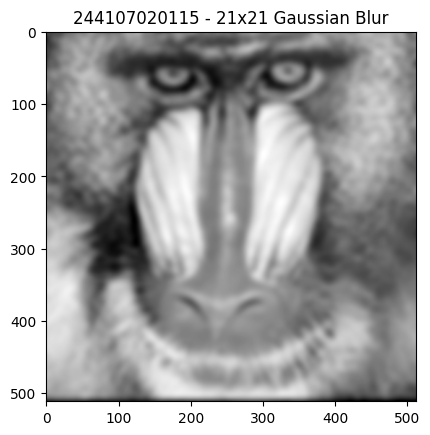

In [14]:
# Filter: 21x21 Gaussian Blur
# Untuk generate kernel gaussian
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

# Catatan: kernel berukuran 21x21 membuat proses konvolusi manual (nested loop) berjalan lebih lama
# dibanding kernel 3x3, karena jumlah perkalian per piksel jauh lebih banyak. Tunggu sampai selesai.
hasil_gaussian21 = convolution2d(img_gray, gauss_kernel, 1, kernel_size // 2)

plt.imshow(hasil_gaussian21, cmap='gray')
plt.title(NIM + ' - 21x21 Gaussian Blur')
plt.show()


## E. FILTER LIBRARY DAN FILTER MODERN
### Percobaan 1

In [15]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


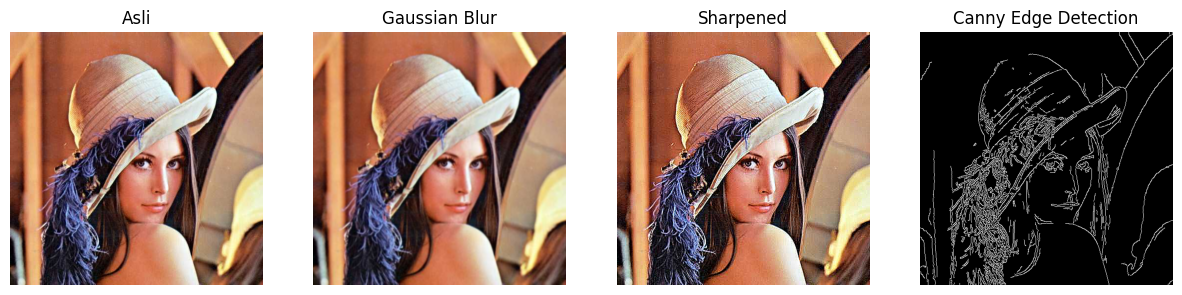

In [16]:
# Percobaan 1 - Gaussian Blur, Sharpen, dan Canny Edge Detection memakai library OpenCV
img = cv.imread("/content/drive/MyDrive/PCVK/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                   ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])


### Percobaan 2

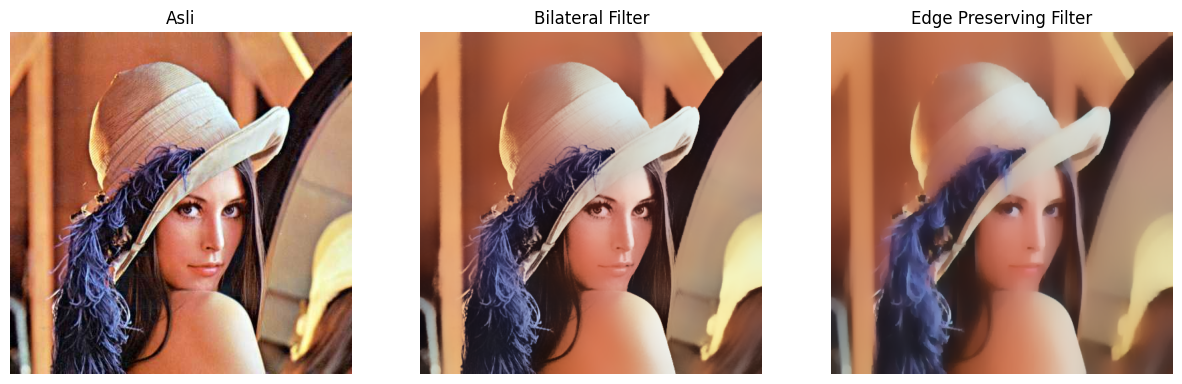

In [17]:

bilateral = cv.bilateralFilter(img, 50, 100, 100)

edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                   ["Asli", "Bilateral Filter", "Edge Preserving Filter"])


### Percobaan 3

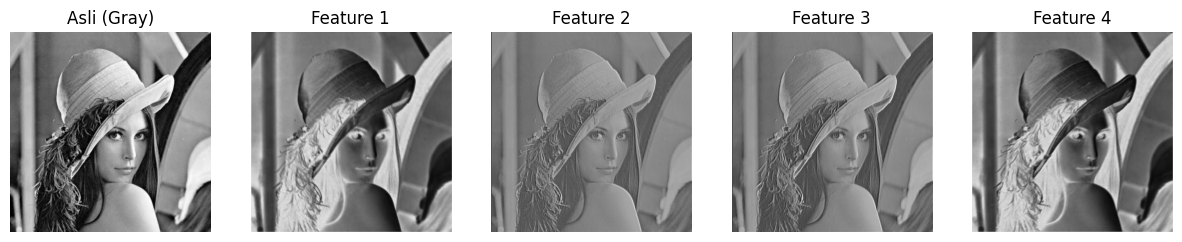

In [18]:
#Filter Feature Map yang digunakan pada CNN, lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])
